# Prescriptive Analytics — Capital Budgeting

**Final Project: Prescriptive Analytics — Capital Budgeting**  

**Student Name:** Aadarsh Nair

**Date:** 4/17/2026

**Chosen context:** A VP must decide which set of projects to fund within a fixed budget

---

## Introduction


This project evaluates how a VP of Operations at a textile manufacturing company can make strategic investment decisions across multiple competing initiatives. Instead of relying on intuition alone, this analysis uses an optimization model to determine which combination of projects will maximize financial return while staying within budget and labor constraints. The goal is to provide a clear, data-driven recommendation that balances profitability, operational feasibility, and risk.

In [1]:
# Required packages are installed when being run in Colab
%pip install pulp pandas matplotlib -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pulp import LpMaximize, LpMinimize, LpProblem, LpVariable, lpSum, value, LpStatus, PULP_CBC_CMD
import io

print("Libraries imported successfully!")

Libraries imported successfully!


**Section 1 — Why This Problem Is Prescriptive**

This problem is prescriptive because the VP must decide which projects to fund under limited resources. Descriptive analytics can summarize past project performance, and predictive analytics can estimate future returns, but neither determines the optimal combination of projects. Prescriptive analytics is required to identify the best portfolio of projects that maximizes total return under constraints.

**Decision Statement**: A VP must decide which set of projects to fund within a fixed budget to maximize total expected return while respecting resource constraints.

**Section 2 — Decision Framing**

**Decision Variables**: Let x_i = 1 if project i is selected, 0 otherwise.

**Projects**:

*   Install Automated Looms
*   Upgrade Dyeing Equipment
*   Expand Warehouse Capacity
*   Implement Energy Efficiency Program
*   Launch Sustainable Fabric Line


**Objective**: Maximize total expected return: Maximize: Sum(Return_i * x_i)

**Constraints**:

*   Total budget cannot exceed $1,000,000
*   Total labor hours cannot exceed 10,000 hours
*   The Sustainable Fabric Line can only be launched if Dyeing Equipment is upgraded


**Key Tradeoffs**:


*   Higher-return projects require more capital and labor
*   Investing in sustainability may reduce short-term return but improve long-term positioning
*   Capacity expansion vs. efficiency improvements

**Section 3 — The Optimization Model**

**Example Data**
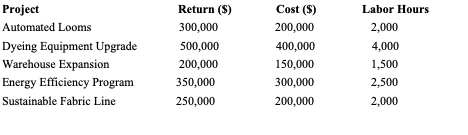

**PuLP Model**


In [3]:
import pulp

# Define model
model = pulp.LpProblem("Textile_Capital_Budgeting", pulp.LpMaximize)

projects = [
    'Automated Looms',
    'Dyeing Upgrade',
    'Warehouse Expansion',
    'Energy Efficiency',
    'Sustainable Line'
]

x = pulp.LpVariable.dicts("Select", projects, cat='Binary')

returns = {
    'Automated Looms':300000,
    'Dyeing Upgrade':500000,
    'Warehouse Expansion':200000,
    'Energy Efficiency':350000,
    'Sustainable Line':250000
}

costs = {
    'Automated Looms':200000,
    'Dyeing Upgrade':400000,
    'Warehouse Expansion':150000,
    'Energy Efficiency':300000,
    'Sustainable Line':200000
}

labor = {
    'Automated Looms':2000,
    'Dyeing Upgrade':4000,
    'Warehouse Expansion':1500,
    'Energy Efficiency':2500,
    'Sustainable Line':2000
}

# Objective
model += pulp.lpSum(returns[i]*x[i] for i in projects)

# Constraints
model += pulp.lpSum(costs[i]*x[i] for i in projects) <= 1000000
model += pulp.lpSum(labor[i]*x[i] for i in projects) <= 10000

# Dependency constraint
model += x['Sustainable Line'] <= x['Dyeing Upgrade']

# Solve
model.solve()

selected = [i for i in projects if x[i].value() == 1]
selected, pulp.value(model.objective)

(['Automated Looms',
  'Dyeing Upgrade',
  'Warehouse Expansion',
  'Sustainable Line'],
 1250000.0)

**Interpretation**: The model selects Automated Looms, Dyeing Equipment Upgrade, Warehouse Expansion, and the Sustainable Fabric Line. This combination yields a maximum expected return of 1,250,000 dollars while satisfying the 1,000,000 dollar budget and 10,000 labor-hour constraints, as well as the dependency that the Sustainable Line requires the Dyeing Upgrade. In practical terms, the VP should prioritize these four investments because, together, they deliver the highest total return among all feasible portfolios under the current assumptions.

**Section 4 — Sensitivity Analysis**

**Key uncertain parameters**:

1.   Expected return from the Dyeing Equipment Upgrade
2.   Cost of the Energy Efficiency Program
3.   Available labor hours

Each parameter is varied by ±20%, and the model is re-solved to observe how the optimal objective value (total return) changes.

In [4]:
#Sensitivity Analysis Code

import pandas as pd
import matplotlib.pyplot as plt
import pulp

# Base values
base_returns = returns.copy()
base_costs = costs.copy()
base_labor_limit = 10000

results = []

scenarios = [
    ("Dyeing Return -20%", {"returns": {"Dyeing Upgrade": base_returns['Dyeing Upgrade'] * 0.8}}),
    ("Dyeing Return +20%", {"returns": {"Dyeing Upgrade": base_returns['Dyeing Upgrade'] * 1.2}}),
    ("Energy Cost -20%", {"costs": {"Energy Efficiency": base_costs['Energy Efficiency'] * 0.8}}),
    ("Energy Cost +20%", {"costs": {"Energy Efficiency": base_costs['Energy Efficiency'] * 1.2}}),
    ("Labor -20%", {"labor_limit": base_labor_limit * 0.8}),
    ("Labor +20%", {"labor_limit": base_labor_limit * 1.2})
]

# Function to solve model

def solve_model(returns_mod, costs_mod, labor_limit):
    model = pulp.LpProblem("Sensitivity", pulp.LpMaximize)
    x = pulp.LpVariable.dicts("Select", projects, cat='Binary')

    model += pulp.lpSum(returns_mod[i]*x[i] for i in projects)
    model += pulp.lpSum(costs_mod[i]*x[i] for i in projects) <= 1000000
    model += pulp.lpSum(labor[i]*x[i] for i in projects) <= labor_limit
    model += x['Sustainable Line'] <= x['Dyeing Upgrade']

    model.solve()
    return pulp.value(model.objective)

    # Base case
base_obj = solve_model(base_returns, base_costs, base_labor_limit)
results.append(("Base Case", base_obj))

# Run scenarios
for name, changes in scenarios:
    returns_mod = base_returns.copy()
    costs_mod = base_costs.copy()
    labor_limit = base_labor_limit

    if "returns" in changes:
        returns_mod.update(changes["returns"])
    if "costs" in changes:
        costs_mod.update(changes["costs"])
    if "labor_limit" in changes:
        labor_limit = changes["labor_limit"]

    obj = solve_model(returns_mod, costs_mod, labor_limit)
    results.append((name, obj))

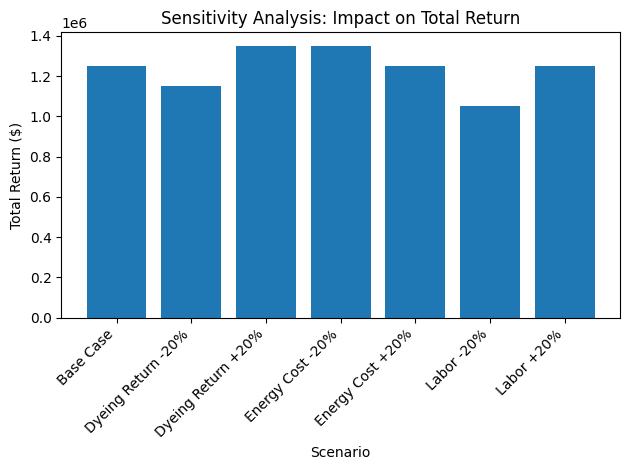

In [5]:
# Creating the visualization
df = pd.DataFrame(results, columns=["Scenario", "Total Return"])

# Plot
plt.figure()
plt.bar(df["Scenario"], df["Total Return"])
plt.xticks(rotation=45, ha='right')
plt.title("Sensitivity Analysis: Impact on Total Return")
plt.xlabel("Scenario")
plt.ylabel("Total Return ($)")
plt.tight_layout()
plt.show()

**Findings**:

*   Dyeing Equipment Upgrade Return: The recommendation is fragile to this parameter. Changes of ±20% significantly impact total return and can alter which projects are selected, indicating this is a critical driver of the model.
*  Energy Efficiency Program Cost: The recommendation is moderately robust to this parameter. While increasing costs can cause the project to be dropped, the overall portfolio remains relatively stable unless costs rise substantially.
*  The recommendation is moderately robust, but becomes more constrained when labor is reduced. A 20% decrease in labor limits the ability to undertake multiple large projects simultaneously, potentially changing the optimal mix.

**Conclusion**:

The VP should have moderate confidence in this recommendation, as the model remains stable under reasonable variations in most parameters. However, the results are highly dependent on the expected return of the Dyeing Equipment Upgrade, which plays a central role in the optimal portfolio. The recommendation would likely change if the projected return of this project decreases significantly or if labor availability becomes more constrained than expected.

**Section 5 — Time Dimension**

The recommended projects are implemented over a 12-month period using a phased rollout that reflects both resource constraints and operational priorities. Only the four selected projects—Automated Looms, Dyeing Equipment Upgrade, Warehouse Expansion, and the Sustainable Fabric Line—are included, ensuring consistency with the optimization results.

**Implementation Timeline**:

*   Q1–Q2: Automated Looms installation and Dyeing Equipment Upgrade
*   Q3: Warehouse Expansion
*   Q4: Sustainable Fabric Line launch (enabled by the dyeing upgrade)

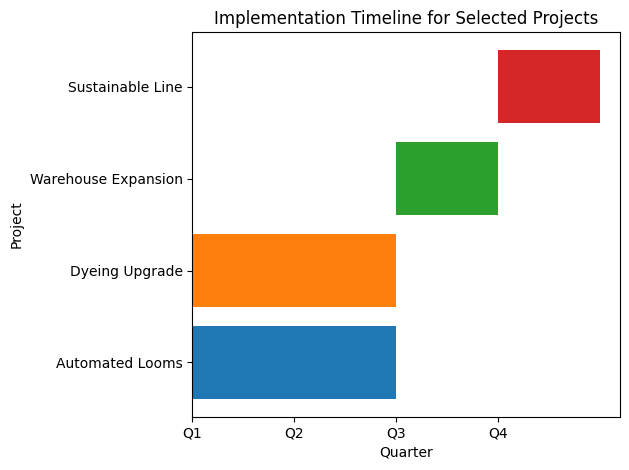

In [6]:
#Visualization Code (Project Timeline)

import matplotlib.pyplot as plt

projects_timeline = {
    "Automated Looms": (1, 2),
    "Dyeing Upgrade": (1, 2),
    "Energy Efficiency": (2, 3),
    "Warehouse Expansion": (3, 4),
    "Sustainable Line": (3, 4)
}

plt.figure()

for i, (project, (start, end)) in enumerate(projects_timeline.items()):
    plt.barh(project, end - start, left=start)

plt.xlabel("Quarter")
plt.ylabel("Project")
plt.title("Project Implementation Timeline Over 12 Months")
plt.xticks([1, 2, 3, 4], ["Q1", "Q2", "Q3", "Q4"])
plt.tight_layout()
plt.show()

**Explanation**:

This sequencing prioritizes high-impact operational improvements early in the year, allowing the company to realize efficiency gains before expanding capacity and launching new products. It also prevents labor bottlenecks by avoiding overlap between the most resource-intensive projects.

Notably, the Energy Efficiency Program is excluded from this timeline because it was not selected in the optimal solution. While it provides value, it is outperformed by other projects under the current budget and labor constraints.

**Section 6 — Where This Model Simplifies Reality**

The model assumes that returns scale linearly with investment, but several relationships in this textile context are likely nonlinear.

**Automated Looms**: Initial automation delivers large efficiency gains, but additional looms create diminishing returns as other stages like dyeing and finishing become bottlenecks. Doubling loom capacity would not double total output.

**Dyeing Equipment Upgrade**: Returns depend on utilization. If demand is lower than expected, the equipment may be underused, reducing returns. At high usage, maintenance and inefficiencies limit gains, so output does not scale proportionally.

**Sustainable Fabric Line**: Early production benefits from premium pricing, but as output increases, market saturation and competition can reduce margins. Doubling production may not double revenue.

**Energy Efficiency Program**: Savings often occur only after full implementation. Partial investments may yield minimal benefits, creating a threshold effect rather than steady, proportional returns.

**Implication**: These nonlinearities mean the model may overstate precision and mis-rank projects near the cutoff. The VP should treat the results as a strong starting point and validate key assumptions—especially demand and capacity—before making final decisions.

**Section 7 — Recommendation**

I recommend funding the Dyeing Equipment Upgrade, Automated Looms, Warehouse Expansion, and the Sustainable Fabric Line, because this combination delivers the highest total return of approximately $1.25M while remaining within both budget and labor constraints, as shown in the optimization results and supported by the sensitivity analysis in Section 4. The "Sensitivity Analysis: Impact on Total Return" chart in section 4 also highlights that this recommendation is particularly dependent on the expected return of the dyeing upgrade, making it the most critical assumption. Additionally, the implementation timeline in Section 5 (which can be see in the "Project Implementation Timeline Over 12 Months" chart) demonstrates that these projects can be realistically executed in phases without exceeding operational capacity.

Before acting, we should validate the projected return of the Dyeing Equipment Upgrade and confirm that labor resources will be available during peak implementation periods. The first step is to conduct a detailed review with operations and finance teams to refine return estimates and finalize a feasible project rollout schedule.